In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

employee_data = pd.read_csv("PreEmployeeAttrition.csv")
employee_data.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,49,279,8,1,2,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1373,2,2,4,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,33,1392,3,4,5,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,27,591,2,1,7,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0


### Separating features and target

In [17]:
target = employee_data["Attrition_Yes"]
features = employee_data.drop("Attrition_Yes", axis=1)

In [18]:
target.value_counts()

Attrition_Yes
0    1233
1     237
Name: count, dtype: int64

### Selection

In [19]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

selector = SelectKBest(score_func=chi2,k=12)
selected_X = selector.fit_transform(features,target)
selected_columns = features.columns[selector.get_support()]

selected_columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeNumber',
       'MonthlyIncome', 'MonthlyRate', 'TotalWorkingYears', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsWithCurrManager',
       'JobRole_Sales Representative', 'OverTime_Yes'],
      dtype='object')

In [20]:
selected_dataset = employee_data[selected_columns]
selected_dataset.head()

,Age,DailyRate,DistanceFromHome,EmployeeNumber,MonthlyIncome,MonthlyRate,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,JobRole_Sales Representative,OverTime_Yes
0,41,1102,1,1,5993,19479,8,6,4,5,0,1
1,49,279,8,2,5130,24907,10,10,7,7,0,0
2,37,1373,2,4,2090,2396,7,0,0,0,0,1
3,33,1392,3,5,2909,23159,8,8,7,0,0,1
4,27,591,2,7,3468,16632,6,2,2,2,0,0


In [21]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(selected_dataset,target,test_size=0.25,random_state=42)

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

parameter_grid = {"n_estimators":[100,200],"criterion":["gini","entropy"],"max_features":["sqrt","log2"]}


grid_search = GridSearchCV(RandomForestClassifier(class_weight="balanced",random_state=42),
    parameter_grid,scoring="accuracy",cv=5,n_jobs=-1)

grid_search.fit(x_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [23]:
best_model = grid_search.best_estimator_

best_model  

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
print("Best Accuracy:", grid_search.best_score_)

Best Accuracy: 0.8484533113944879


### Test Accuracy

In [25]:
from sklearn.metrics import accuracy_score

predictions = best_model.predict(x_test)
accuracy_score(y_test,predictions)

0.8586956521739131

### Report

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       320
           1       0.33      0.08      0.13        48

    accuracy                           0.86       368
   macro avg       0.60      0.53      0.53       368
weighted avg       0.81      0.86      0.82       368



### Confusion Matrix

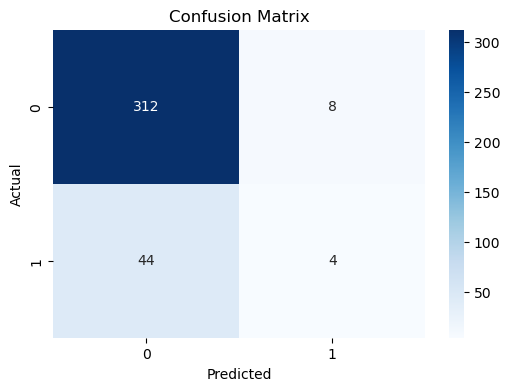

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

confusion_matrix(y_test, predictions)
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Saving the Model

In [28]:
import pickle

pickle.dump(best_model,open("AttritionModel.sav","wb"))
pickle.dump(list(selected_columns),open("SelectedFeatures.sav","wb"))
pickle.dump(list(features.columns),open("encoder_columns.sav","wb"))

### Verification

In [29]:
pickle.load(open("SelectedFeatures.sav","rb"))

['Age',
 'DailyRate',
 'DistanceFromHome',
 'EmployeeNumber',
 'MonthlyIncome',
 'MonthlyRate',
 'TotalWorkingYears',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsWithCurrManager',
 'JobRole_Sales Representative',
 'OverTime_Yes']